In [37]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

In [61]:
def getCSV():
    raw_df = pd.read_csv(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\PersonsWorkCounty.csv')
    return raw_df
df = getCSV()
print(set(list(df["Statistic Label"])))

{'Income of Self Employed', 'Index of Disposable Income per Person (excluding Rent)', 'Rent of dwellings (including imputed rent of owner-occupied dwellings)', 'Disposable Income per Person (excluding Rent)', 'Index of Disposable Income per Person', 'Social Benefits and Other Current Transfers', 'Total Income per Person', "Compensation of Employees (i.e. Wages and Salaries, Benefits in kind, Employers' social insurance contribution)", 'Index of Total Income per Person', 'Disposable Income per Person', 'Social Benefits and Other Current Transfers per Person', 'Current Taxes on Income', 'Percentage of Persons at Work', 'Disposable Household Income', 'Total Household Income', 'Persons at Work', 'Net Interest and Dividends (payments by households of interest are deducted from interest received by households)', 'Primary Income'}


In [62]:
df = df[df["County"]!="Ireland"]

In [63]:
df["County"] = df["County"].apply(lambda x : x[3:].upper())
df['County'] = df['County'].str.strip()

In [64]:
counties_shapefile = gpd.read_file(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\Ireland_Counties\Counties___Ungen_2019.shp')
counties_shapefile['ENGLISH'] = counties_shapefile['ENGLISH'].str.strip()

In [88]:
year = 2000
label = "Total Income per Person"
filtered_df = df[(df["Statistic Label"]=="Total Income per Person") & (df["Year"]==year)]

In [89]:
def mergeData(df):
    merged_data = counties_shapefile.merge(df, how='left', left_on='ENGLISH', right_on='County')
    return merged_data
merged_data = mergeData(filtered_df)

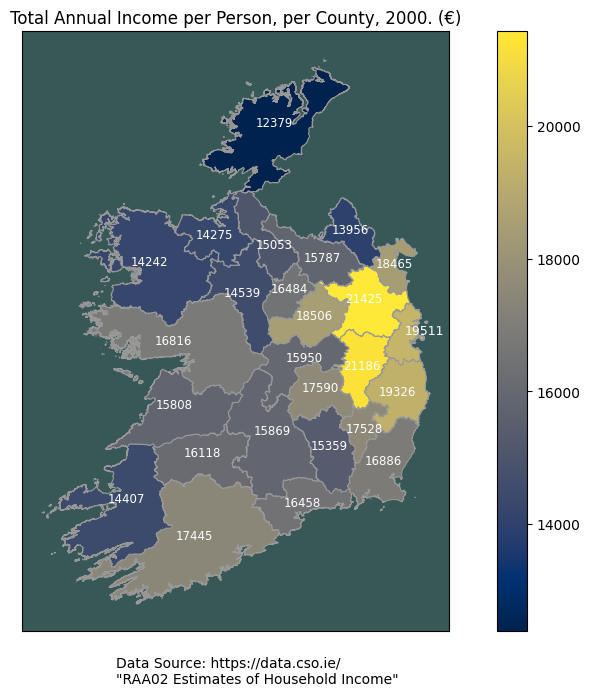

In [90]:
import numpy as np

#column containing the population values
column_to_plot = 'VALUE'

# merged_data['scaled_value'] = np.log1p(merged_data['VALUE'])

#plot the populastion data for the selcted year on the map generated by the shapefile
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged_data.plot(column=column_to_plot, cmap='cividis', linewidth=0.8, ax=ax, edgecolor='0.60', legend=True)

text_color = "#FEFEFE"
font_size = 8.5
for idx,row in merged_data.iterrows():
    raw_pop_of_county = int(row['VALUE'])
    if row['ENGLISH'] == "DUBLIN":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+15000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                        color="#FFFFFF", 
                        fontsize=font_size+.5, 
                        ha='center')
    elif row['ENGLISH'] == "OFFALY":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X'], row['CENTROID_Y']+9000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "CORK":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+14000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "KILKENNY":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+4000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "WESTMEATH":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+4000, row['CENTROID_Y']-3000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "SLIGO":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X'], row['CENTROID_Y']-7000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "ROSCOMMON":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+4000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "LEITRIM":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+7000, row['CENTROID_Y']-10000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "KERRY":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+16000, row['CENTROID_Y']+3000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    elif row['ENGLISH'] == "CAVAN":
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X']+8000, row['CENTROID_Y']-9000),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')
    else:
        plt.annotate(text=str(raw_pop_of_county), 
                        xy=(row['CENTROID_X'], row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                        color=text_color, 
                        fontsize=font_size, 
                        ha='center')  # Adjust ha and va as needed

title_string = "Total Annual Income per Person, per County, "+str(year)+". (€)"
ax.set_title(title_string)
ax.set_facecolor('#385757') 
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15)
plt.text(0.22, -0.086, "Data Source: https://data.cso.ie/ \n\"RAA02 Estimates of Household Income\"", ha='left', transform=ax.transAxes)

plt.savefig('TotalAnnualIncomeCounty-'+str(year)+'.png')
plt.show()

In [198]:
df = getCSV()
print(set(list(df["Statistic Label"])))
df["County"] = df["County"].apply(lambda x : x[3:].strip())

{'Income of Self Employed', 'Index of Disposable Income per Person (excluding Rent)', 'Rent of dwellings (including imputed rent of owner-occupied dwellings)', 'Disposable Income per Person (excluding Rent)', 'Index of Disposable Income per Person', 'Social Benefits and Other Current Transfers', 'Total Income per Person', "Compensation of Employees (i.e. Wages and Salaries, Benefits in kind, Employers' social insurance contribution)", 'Index of Total Income per Person', 'Disposable Income per Person', 'Social Benefits and Other Current Transfers per Person', 'Current Taxes on Income', 'Percentage of Persons at Work', 'Disposable Household Income', 'Total Household Income', 'Persons at Work', 'Net Interest and Dividends (payments by households of interest are deducted from interest received by households)', 'Primary Income'}


In [199]:
county1="Dublin"
county2="Cork"
county3="Galway"
label = "Percentage of Persons at Work"
c1_df = df[(df["Statistic Label"]==label) & (df["County"]==county1)]
c2_df = df[(df["Statistic Label"]==label) & (df["County"]==county2)]
c3_df = df[(df["Statistic Label"]==label) & (df["County"]==county3)]

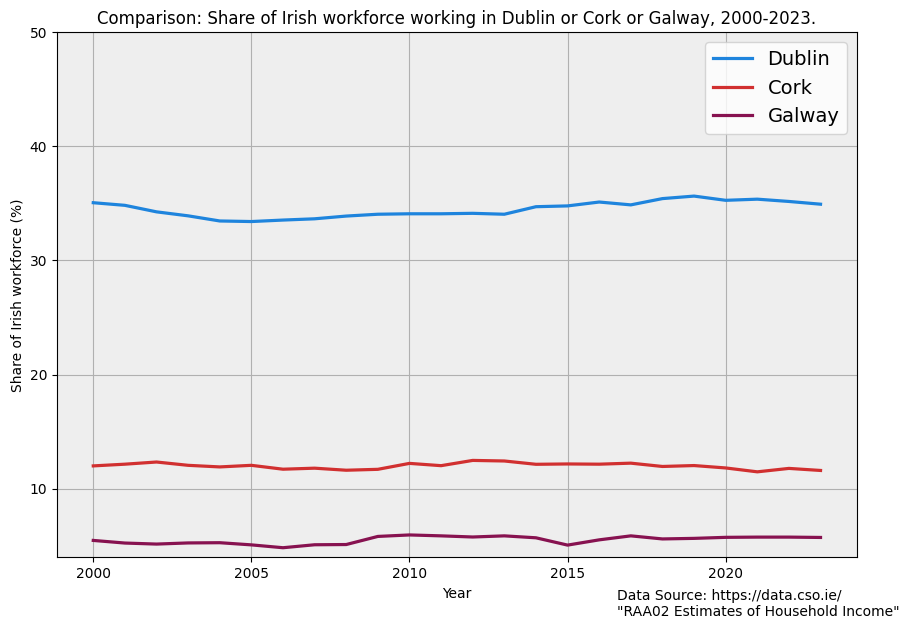

In [206]:
fig, ax = plt.subplots(1,1,figsize=(10,7))

c1_df.plot(x="Year", y="VALUE", color="#1E84DD",linewidth=2.3, ax=ax, label=county1)
c2_df.plot(x="Year", y="VALUE", color="#D13030",linewidth=2.3, ax=ax, label=county2)
c3_df.plot(x="Year", y="VALUE", color="#871250",linewidth=2.3, ax=ax, label=county3)

title_string = "Comparison: Share of Irish workforce working in "+county1+" or "+county2+" or "+county3+", 2000-2023."
plt.title(title_string)
plt.xlabel('Year')
plt.ylabel('Share of Irish workforce (%)')
plt.legend(fontsize=14)
ax.set_facecolor('#EEEEEE')
ax.set_ylim(4,50)
plt.grid(True)

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15)
plt.text(0.7, -0.112, "Data Source: https://data.cso.ie/ \n\"RAA02 Estimates of Household Income\"", ha='left', transform=ax.transAxes)

plt.savefig('WorkforceCounties'+county1+county2+county3+'.png')

plt.show()